In [1]:
from PYME.IO.image import ImageStack
from double_helix.DoubleGaussFit import Detector
import matplotlib.pyplot as plt
from scipy import ndimage
import numpy as np
import os
from PYME.recipes.processing import BackgroundSubtractionMovingPercentile
from PYME.localization.remFitBuf import fitTask
# %matplotlib widget
plt.set_loglevel("warning")
from os import path
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from matplotlib import rc
import seaborn as sns
rc('font',**{'family':'sans-serif','sans-serif':['Arial']})
fontsize = 11

In [2]:
fight_club_LD_DH = ImageStack(filename = "C:/Users/Administrator/PYMEData/SR_Fightclub_DH_Data/MT0_N1_LD_DH/sequence-as-stack-MT0.N1.LD-DH-Exp.h5", haveGUI=False)

filename == C:\Users\Administrator\PYMEData\SR_Fightclub_DH_Data\MT0_N1_LD_DH\sequence-as-stack-MT0.N1.LD-DH-Exp.h5
C:\Users\Administrator\PYMEData\SR_Fightclub_DH_Data\analysis\MT0_N1_LD_DH\sequence-as-stack-MT0.N1.LD-DH-Exp.h5r


In [3]:
bg_sub = BackgroundSubtractionMovingPercentile().apply_simple(fight_club_LD_DH)

c:\userfiles\code\dh_pyme_dev\PYME\recipes\processing.py:2500: PYMEDeprecationWarning: This will either disappear or change function as we move to a 5D data model. Use the explicit .data_xytc instead, or even better, change to using the 5D model as image.data_xyztc or image.voxels
  bgs = BGSDataSource.DataSource(input_name.data, bgRange=self.window)
c:\userfiles\code\dh_pyme_dev\PYME\IO\MetaDataHandler.py:666: UserWarning: DictMDHandler is not yet fully supported, and will likely cause failures for anything related to localisation fitting
  warnings.warn('DictMDHandler is not yet fully supported, and will likely cause failures for anything related to localisation fitting')


In [4]:
r = np.shape(bg_sub.data_xytc)[0]
c = np.shape(bg_sub.data_xytc)[1]

frame_num = 7062

test_frame = np.empty([r, c])
test_frame_sigma = np.empty([r, c])
test_frame_bg_subbed = np.empty([r, c])



test_frame[:,:] = np.squeeze(fight_club_LD_DH.data_xytc[:,:, frame_num,:]).T
test_frame_bg_subbed[:,:] = np.squeeze(bg_sub.data_xytc[:,:, frame_num,:]).T
test_frame_sigma[:,:] = np.squeeze(fitTask.calcSigma(fight_club_LD_DH.mdh, test_frame[:,:].astype('f'))).T


8
16


In [5]:
detector = Detector(roi_half_size=10, l_initial=1025, lobe_sigma_initial=215, filter_sigma=5.5, px_size_nm=100)

Optimization terminated successfully.
         Current function value: -0.015984
         Iterations: 15
         Function evaluations: 30


In [6]:
strength_image, angle_image = detector.filter_frame(test_frame_bg_subbed)

In [7]:
def lobe_estimate_from_center_pixel(x_pix, y_pix, orientation, lobe_sep_px):
    dx = np.cos(orientation) * lobe_sep_px/2
    dy = np.sin(orientation) * lobe_sep_px/2
    x1 = x_pix - dx
    y1 = y_pix - dy
    x2 = x_pix + dx
    y2 = y_pix + dy
    return x1, y1, x2, y2

In [8]:
output_dir = "G:/Shared drives/WEMpire-LAB/Current_projects/CellImaging-NIH/PYME-DH-fitting/draft_manuscript/Figures/Fig1/"

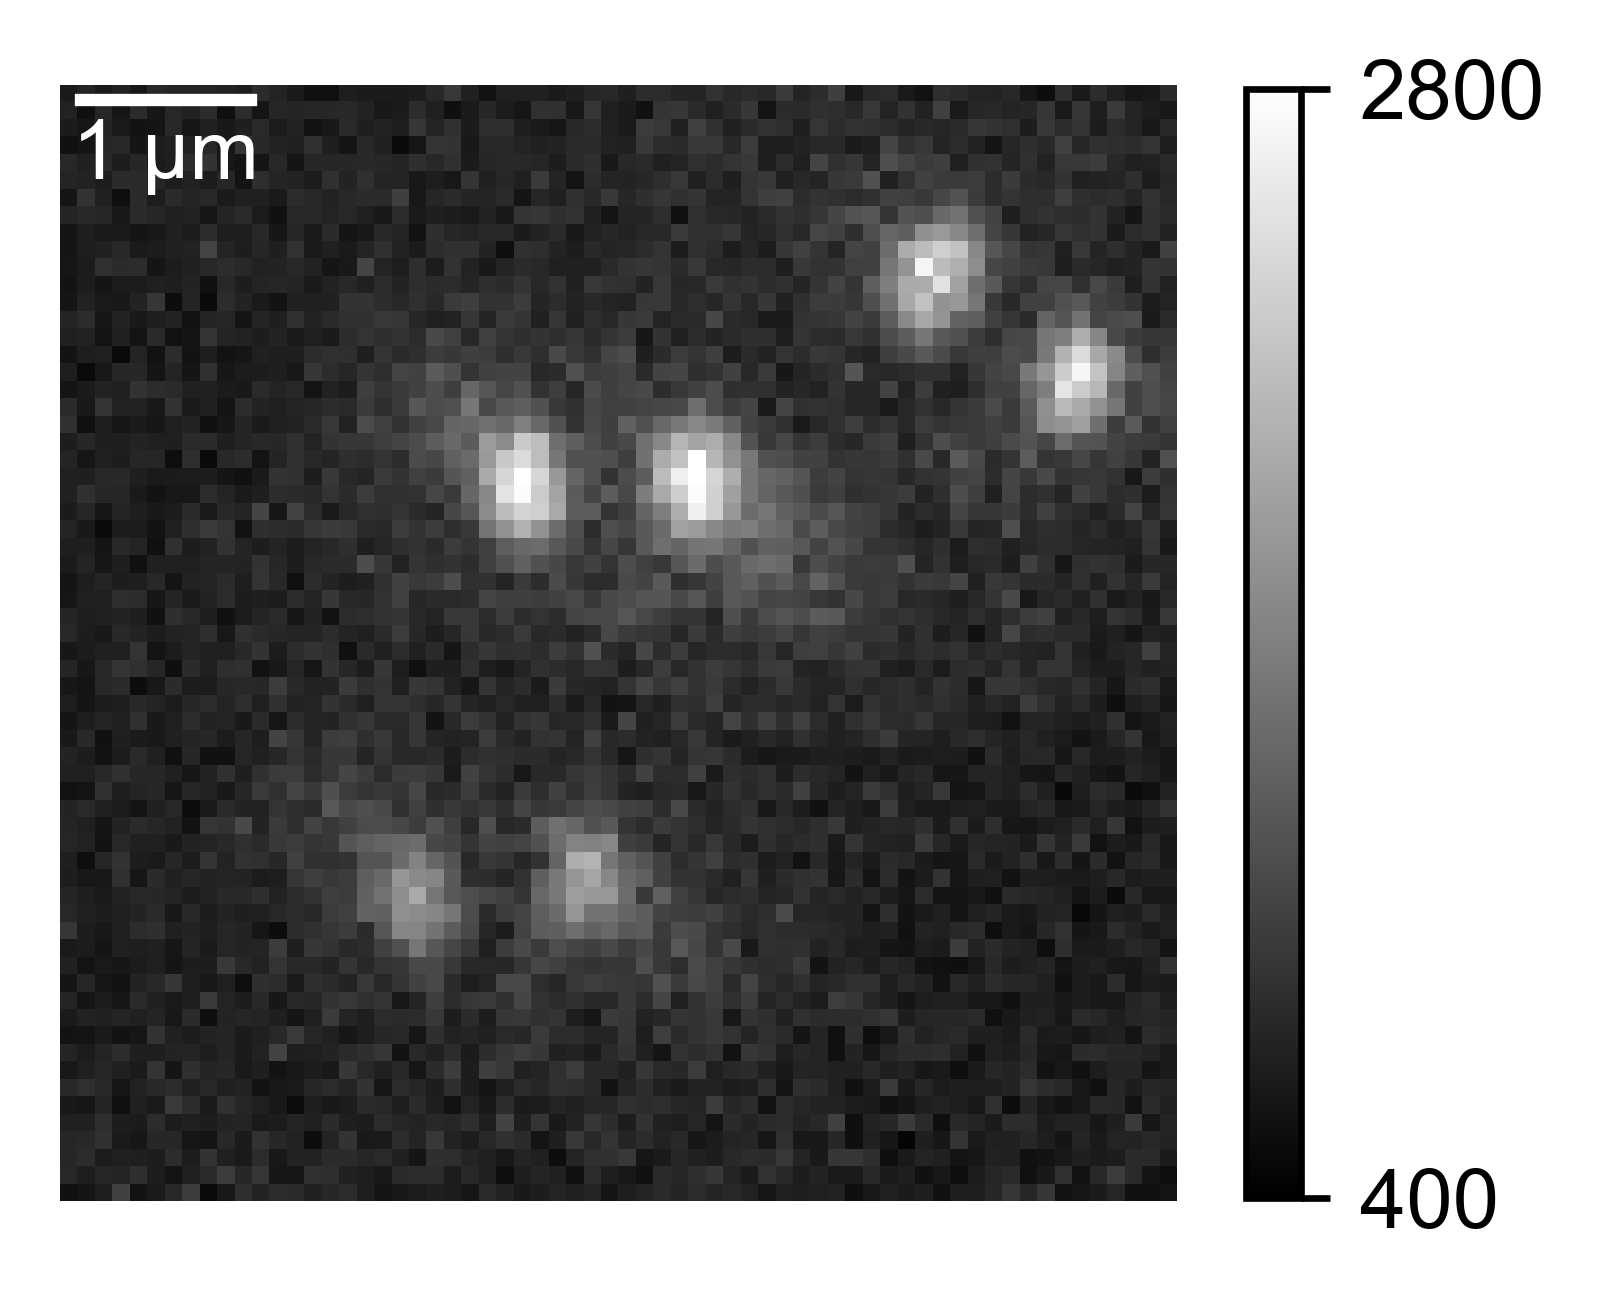

In [35]:
figsize = (3, 3)  # inches
dpi = 600
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

im_to_plot = test_frame
im = ax.imshow(im_to_plot, interpolation='none', cmap='gray', vmin = 400, vmax = 2800) 
ax.set_yticks([])
ax.set_xticks([])
ax.axis('off')

cbar = fig.colorbar(im, ax=ax, shrink=0.8, ticks = [400, 2800])

scalebar_nm = 1000
scalebar_pix = scalebar_nm / 100
scalebar = AnchoredSizeBar(ax.transData,
                           scalebar_pix, '%d \u03BCm' % (scalebar_nm / 1e3), 'upper left', 
                           pad=0.05,
                           color='w',
                           frameon=False,
                           size_vertical=0.25)#,
                        #    fontproperties=fontprops)

ax.add_artist(scalebar)
plt.savefig(path.join(output_dir, "test_frame.svg"), dpi=dpi, bbox_inches='tight')

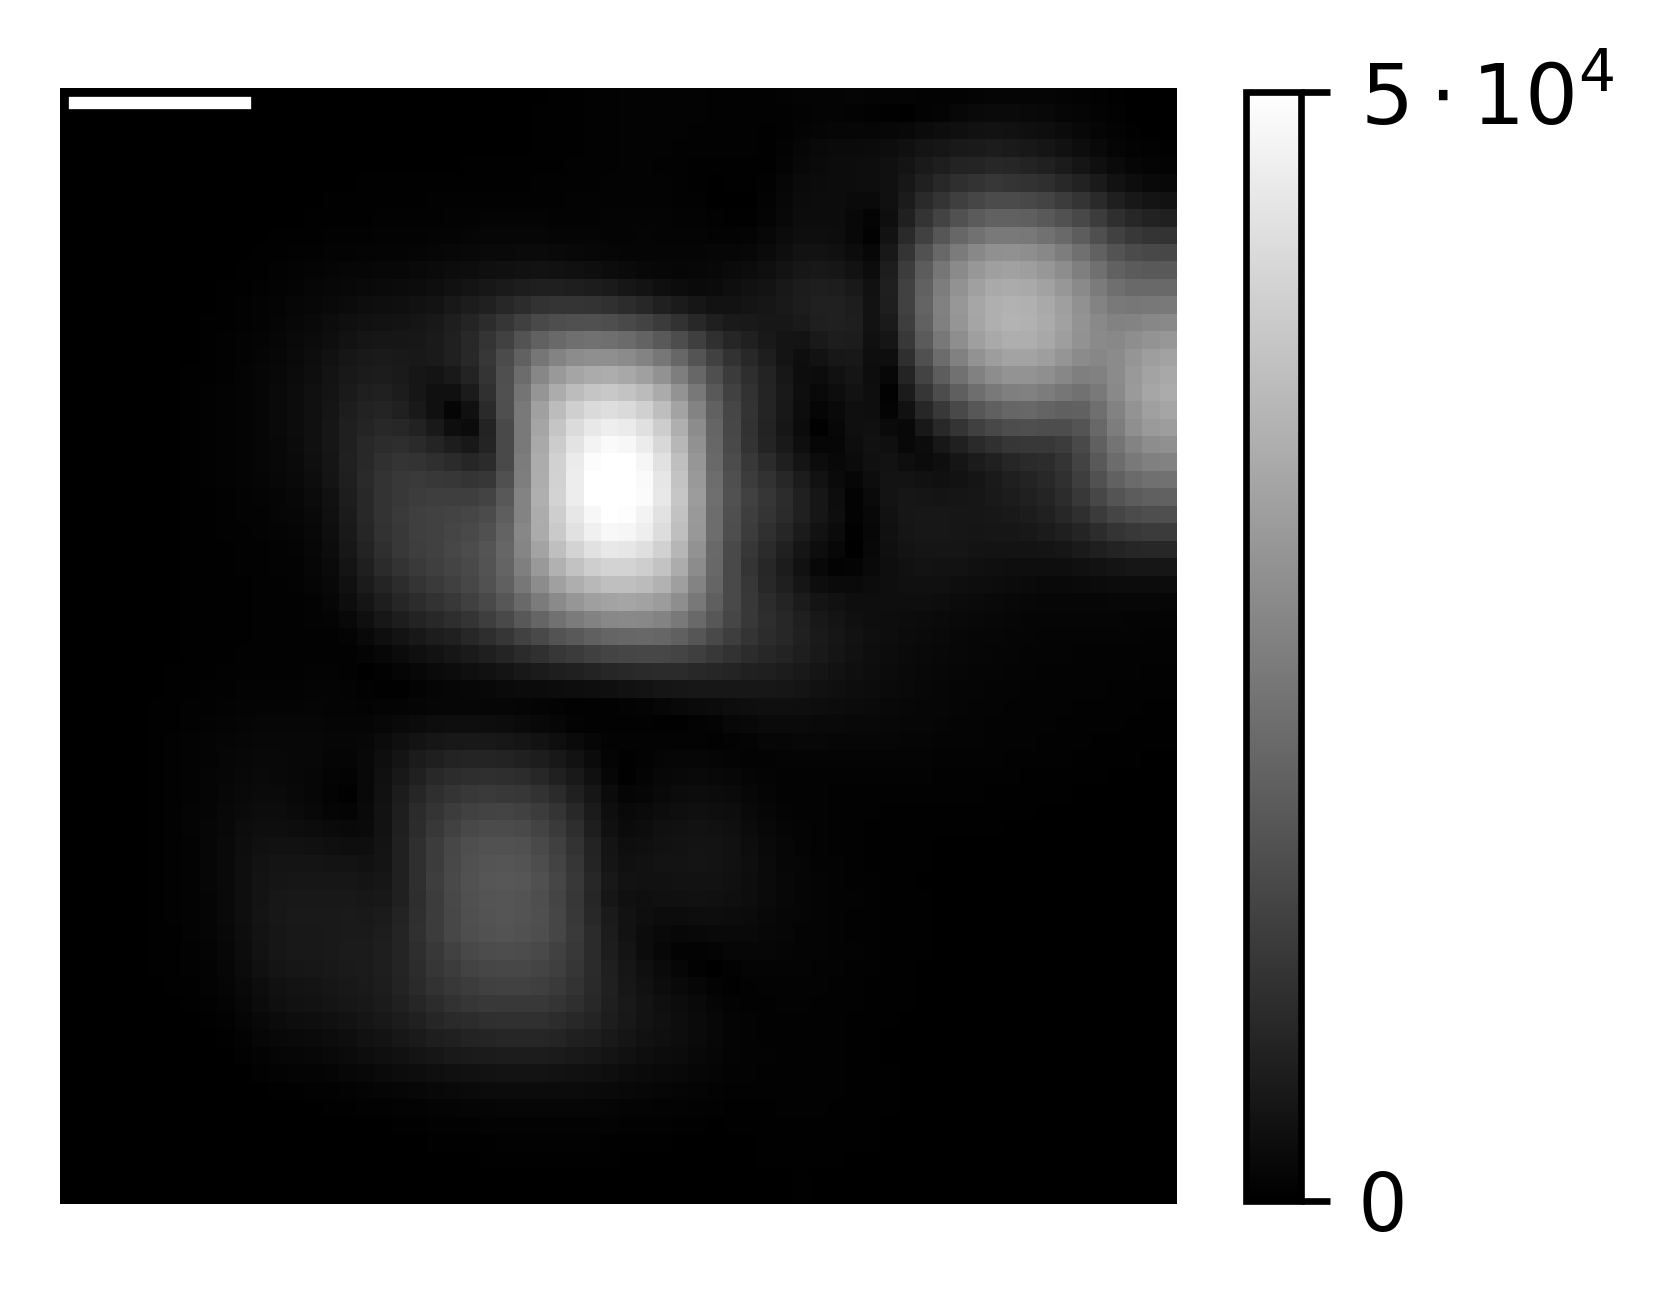

In [46]:
figsize = (3, 3)  # inches
dpi = 600
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

im_to_plot = strength_image
im = ax.imshow(im_to_plot, interpolation='none', cmap='gray', vmin = 0, vmax = 50000) 
ax.set_yticks([])
ax.set_xticks([])
ax.axis('off')

cbar = fig.colorbar(im, ax=ax, shrink=0.8, ticks = [0, 50000])
cbar.ax.set_yticklabels([r'0', r'$5\cdot10^{4}$'])

scalebar_nm = 1000
scalebar_pix = scalebar_nm / 100
scalebar = AnchoredSizeBar(ax.transData,
                           scalebar_pix, '', 'upper left', 
                           pad=0.05,
                           color='w',
                           frameon=False,
                           size_vertical=0.25)#,
                        #    fontproperties=fontprops)


ax.add_artist(scalebar)
plt.savefig(path.join(output_dir, "strength_image.svg"), dpi=dpi, bbox_inches='tight')

13.0


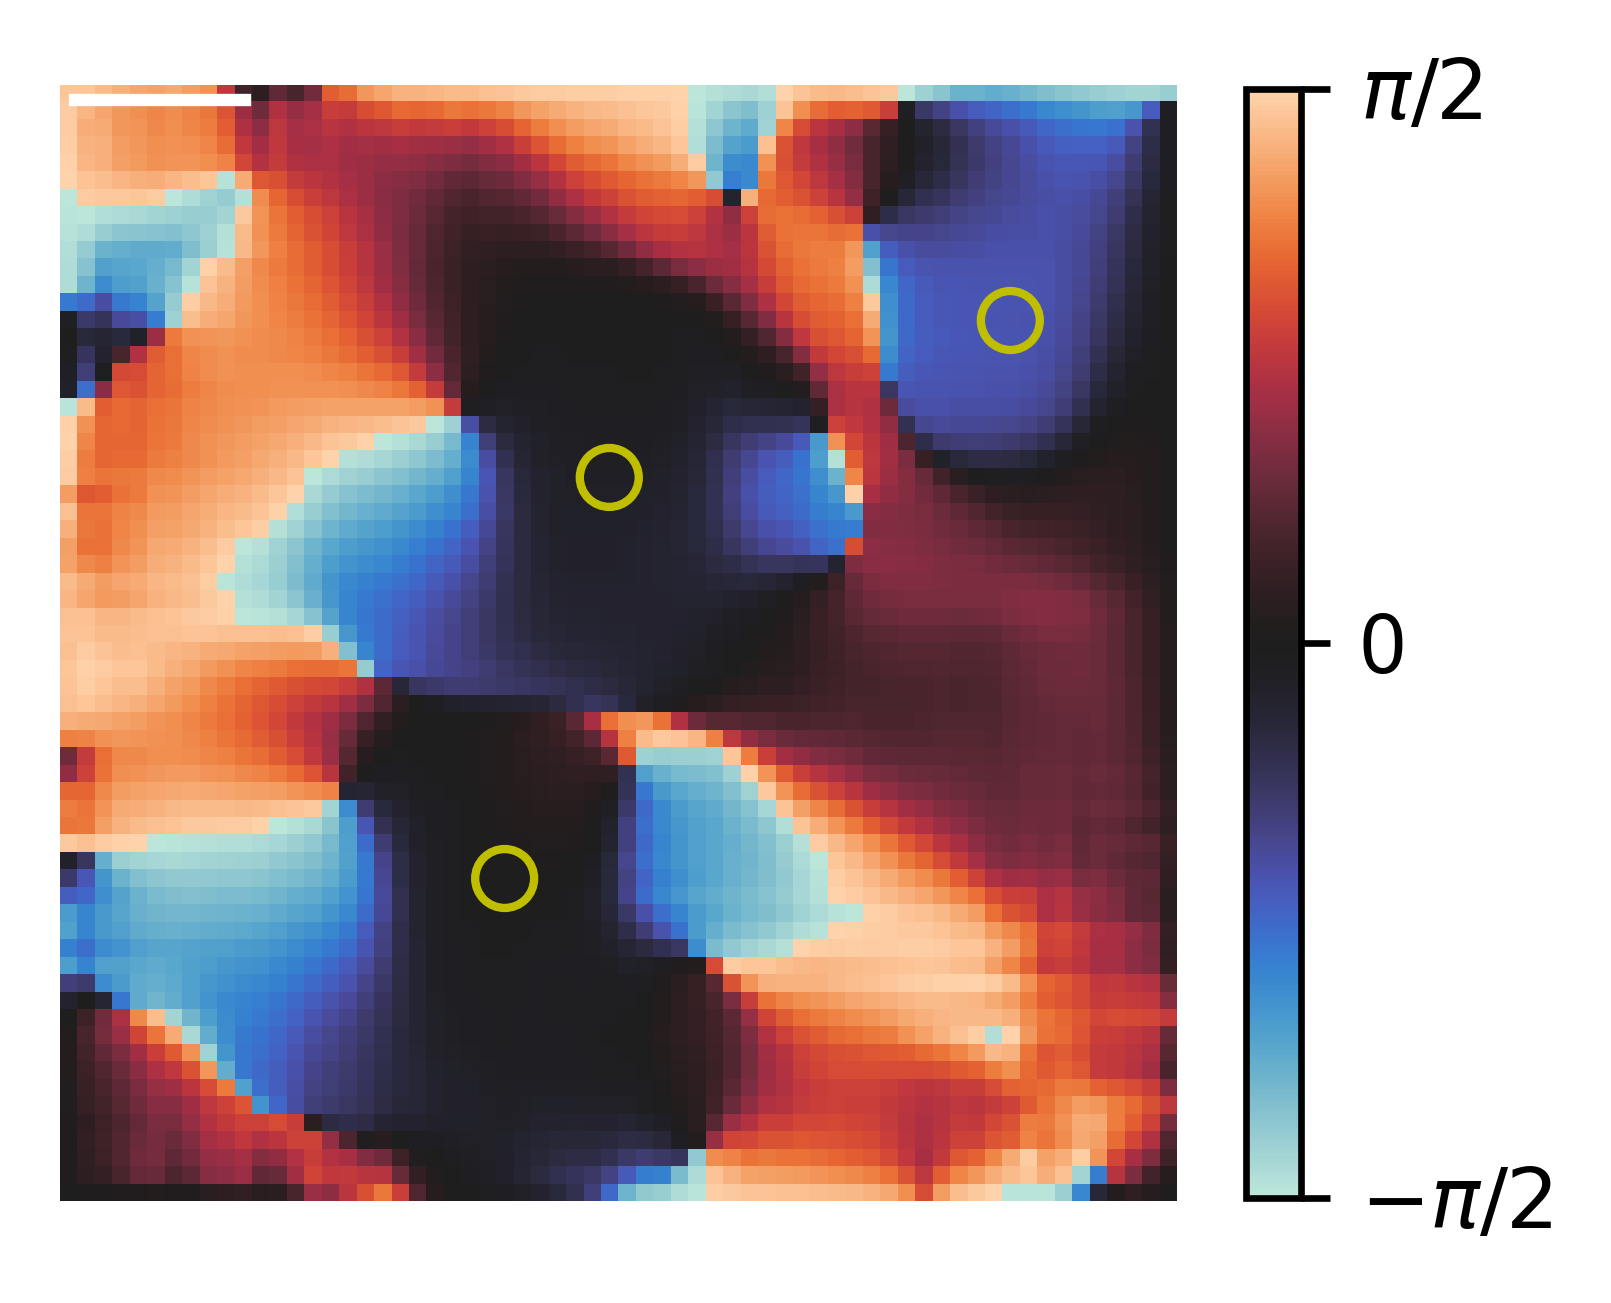

In [27]:
figsize = (3, 3)  # inches
dpi = 600
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

my_cmap = sns.color_palette('icefire', as_cmap=True)

thresh = 1

row, col, orientation = detector.extract_candidates(strength_image, angle_image, (thresh * test_frame_sigma)**2 * detector.normFactor)
    
x1, y1, x2, y2 = lobe_estimate_from_center_pixel(col, row, orientation, 1025/100)
   
x1 = np.delete(x1, 1)
x2 = np.delete(x2, 1)
y1 = np.delete(y1, 1)
y2 = np.delete(y2, 1)

col = np.delete(col, 1)
row = np.delete(row, 1)


im_to_plot = -angle_image
im = ax.imshow(im_to_plot, interpolation='none', cmap=my_cmap, vmin = -1*np.pi/2, vmax=np.pi/2) 
ax.scatter(col, row, edgecolor='y', alpha=1, s=50, facecolor='none')
ax.set_yticks([])
ax.set_xticks([])
ax.axis('off')

cbar = fig.colorbar(im, ax=ax, shrink=0.8, ticks=[-1*np.pi/2, 0, np.pi/2])
cbar.ax.set_yticklabels([r'$-\pi/2$', '0', '$\pi/2$'])



scalebar = AnchoredSizeBar(ax.transData,
                           scalebar_pix, '', 'upper left', 
                           pad=0.05,
                           color='w',
                           frameon=False,
                           size_vertical=0.25)#,
                        #    fontproperties=fontprops)


ax.add_artist(scalebar)


plt.savefig(path.join(output_dir, "angle_image.svg"), dpi=dpi, bbox_inches='tight')

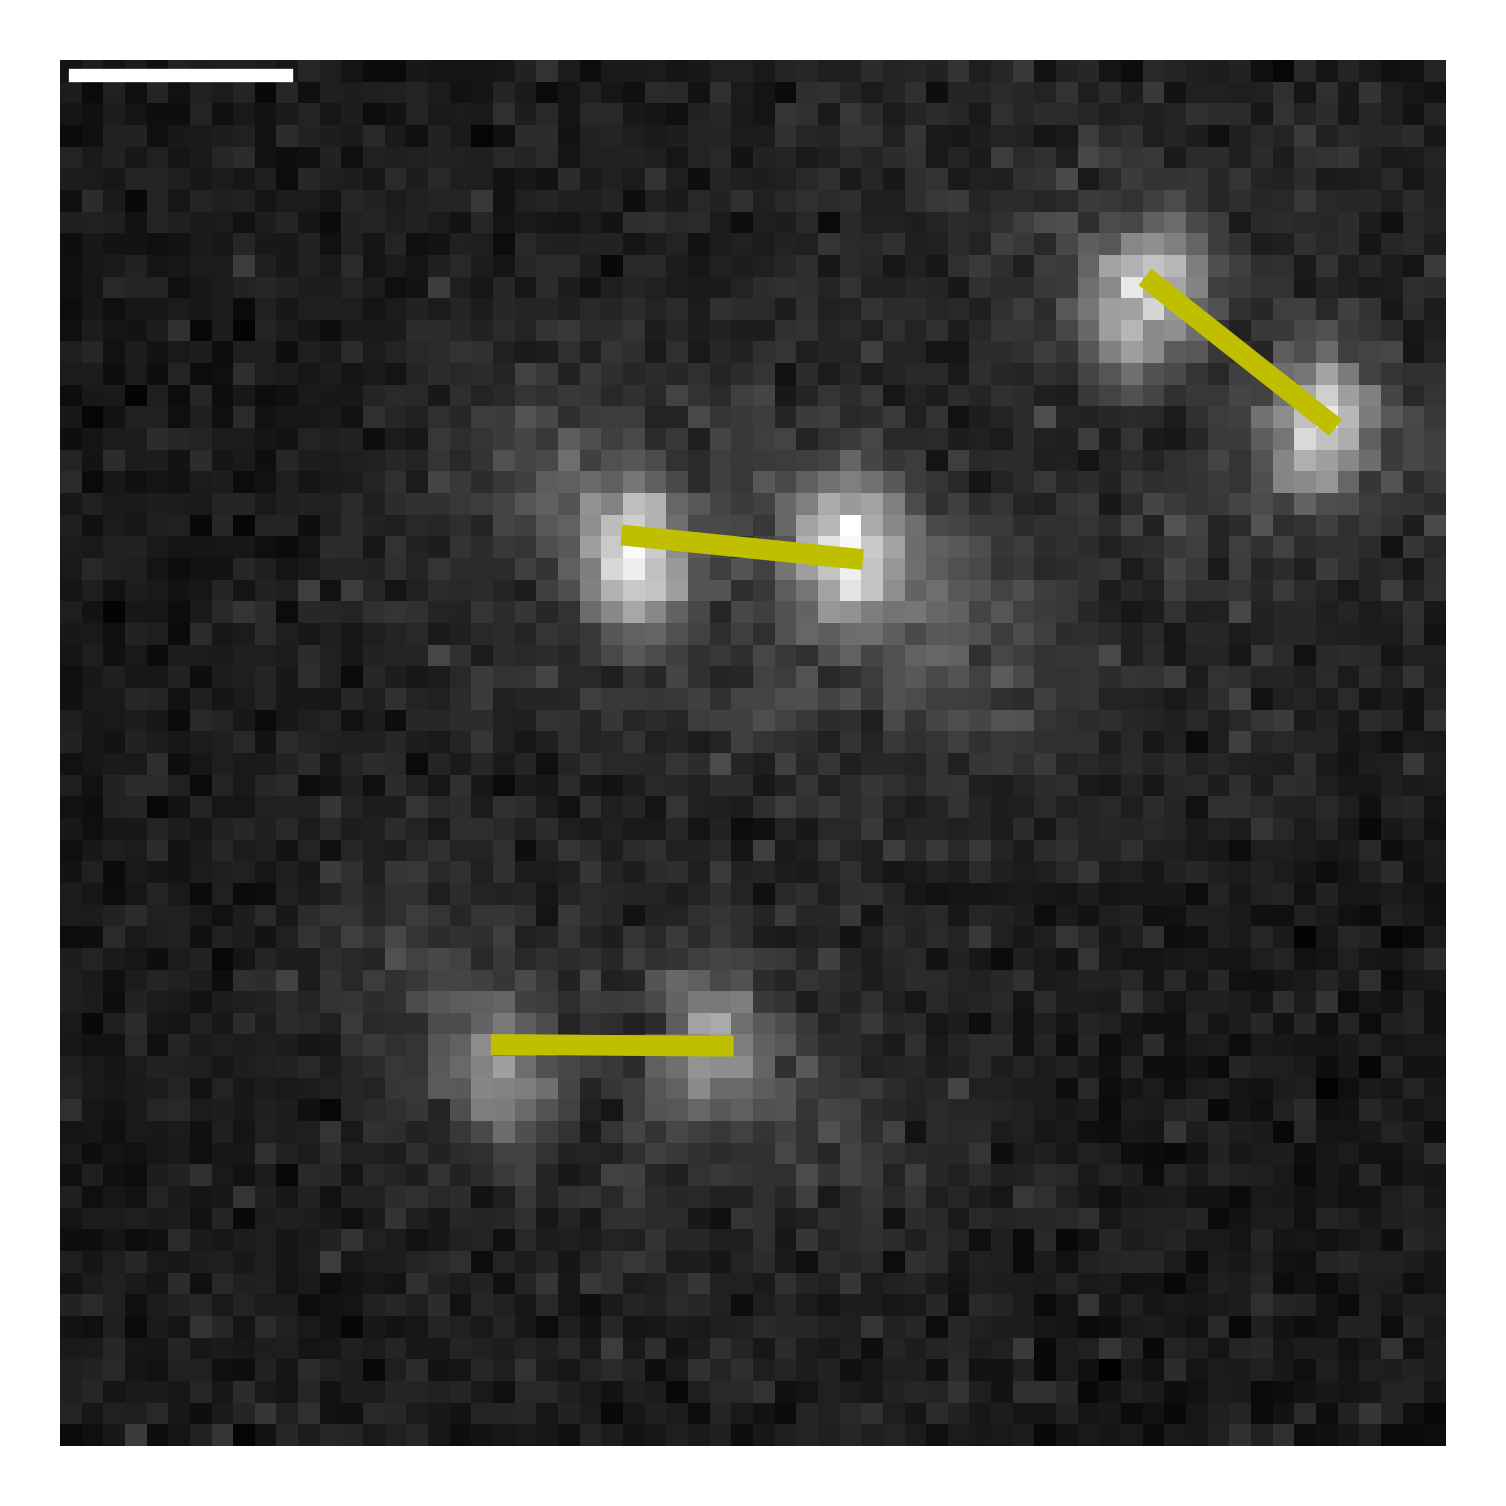

In [12]:
figsize = (3, 3)  # inches
dpi = 600

thresh = 1

fig, ax = plt.subplots(figsize=figsize, dpi=dpi)



    

im_to_plot = test_frame
im = ax.imshow(im_to_plot, interpolation='none', cmap='gray')
ax.plot([x1, x2], [y1, y2], 'y', alpha=1, linewidth=2.5)
ax.set_yticks([])
ax.set_xticks([])
ax.axis('off')

scalebar = AnchoredSizeBar(ax.transData,
                           scalebar_pix, '', 'upper left', 
                           pad=0.05,
                           color='w',
                           frameon=False,
                           size_vertical=0.25)#,
                        #    fontproperties=fontprops)


ax.add_artist(scalebar)

plt.savefig(path.join(output_dir, "detected_DHPSFS_image.svg"), dpi=dpi, bbox_inches='tight')

In [15]:
col

array([54, 31, 25], dtype=int64)

In [16]:
row

array([13, 22, 45], dtype=int64)